<a href="https://colab.research.google.com/github/PittuSaiPrathvik/xyz/blob/main/Student_performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd

data = {
    "Attendance": [95, 88, 76, 65, 92, 55, 70, 83, 60, 98,
                   72, 85, 68, 90, 58, 80, 74, 63, 87, 96],

    "Assignment_Score": [92, 85, 75, 60, 88, 45, 68, 80, 55, 95,
                         72, 83, 65, 90, 50, 78, 70, 58, 84, 94],

    "Internal_Score": [90, 82, 78, 62, 86, 48, 65, 79, 58, 93,
                       74, 81, 68, 88, 52, 76, 72, 60, 85, 91],

    "Study_Hours": [4.5, 4, 3.5, 2.5, 4, 1.5, 2.5, 3.5, 2, 5,
                    3, 4, 2.5, 4, 1.5, 3.5, 3, 2, 4, 5],

    "Previous_Score": [88, 82, 76, 65, 85, 50, 68, 78, 55, 92,
                       73, 80, 67, 86, 52, 75, 70, 62, 83, 90],

    "Outcome": ["Pass", "Pass", "Pass", "Needs Support", "Pass",
                "Needs Support", "Needs Support", "Pass", "Needs Support",
                "Pass", "Pass", "Pass", "Needs Support", "Pass",
                "Needs Support", "Pass", "Pass", "Needs Support",
                "Pass", "Pass"]
}

df = pd.DataFrame(data)

df.head()

,Attendance,Assignment_Score,Internal_Score,Study_Hours,Previous_Score,Outcome
0,95,92,90,4.5,88,Pass
1,88,85,82,4.0,82,Pass
2,76,75,78,3.5,76,Pass
3,65,60,62,2.5,65,Needs Support
4,92,88,86,4.0,85,Pass


In [38]:
df = pd.DataFrame(data)

In [39]:
df.to_csv("student_performance.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [40]:
df.shape

(20, 6)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Attendance        20 non-null     int64  
 1   Assignment_Score  20 non-null     int64  
 2   Internal_Score    20 non-null     int64  
 3   Study_Hours       20 non-null     float64
 4   Previous_Score    20 non-null     int64  
 5   Outcome           20 non-null     object 
dtypes: float64(1), int64(4), object(1)
memory usage: 1.1+ KB


In [42]:
df.describe()

,Attendance,Assignment_Score,Internal_Score,Study_Hours,Previous_Score
count,20.000000,20.000000,20.00000,20.000000,20.000000
mean,77.750000,74.350000,74.40000,3.275000,73.850000
std,13.529208,15.107597,13.37476,1.069616,12.545811
min,55.000000,45.000000,48.00000,1.500000,50.000000
25%,67.250000,63.750000,64.25000,2.500000,66.500000
50%,78.000000,76.500000,77.00000,3.500000,75.500000
75%,88.500000,85.750000,85.25000,4.000000,83.500000
max,98.000000,95.000000,93.00000,5.000000,92.000000


In [43]:
df["Outcome"].value_counts()

,count
Outcome,
Pass,13
Needs Support,7


In [44]:
df.isnull().sum()

,0
Attendance,0
Assignment_Score,0
Internal_Score,0
Study_Hours,0
Previous_Score,0
Outcome,0


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

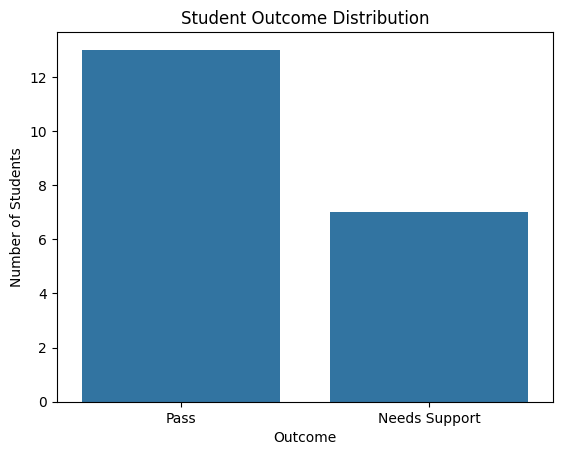

In [47]:
sns.countplot(data=df, x="Outcome")

plt.title("Student Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.show()

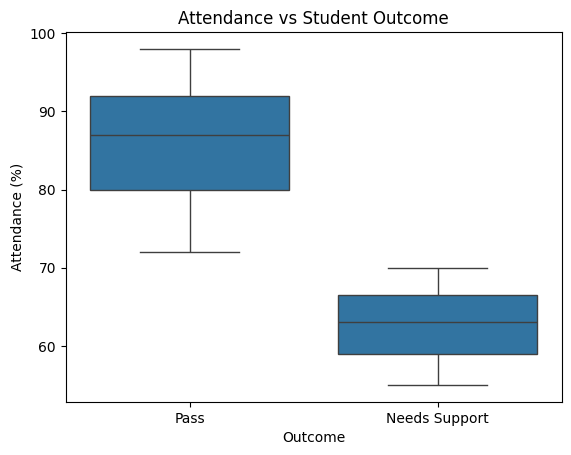

In [48]:
sns.boxplot(data=df, x="Outcome", y="Attendance")

plt.title("Attendance vs Student Outcome")
plt.xlabel("Outcome")
plt.ylabel("Attendance (%)")
plt.show()

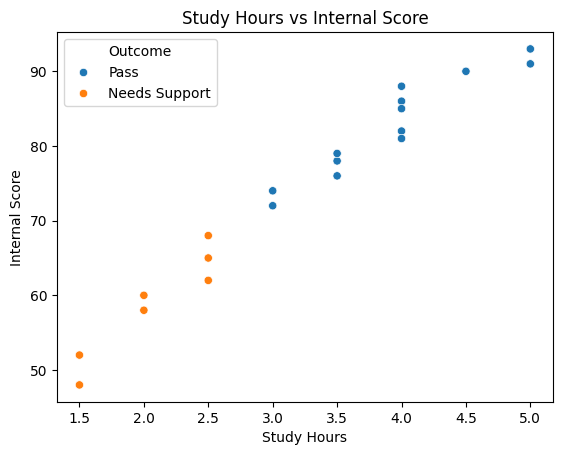

In [49]:
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Internal_Score",
    hue="Outcome"
)

plt.title("Study Hours vs Internal Score")
plt.xlabel("Study Hours")
plt.ylabel("Internal Score")
plt.show()

In [50]:
numeric_df = df.drop(columns=["Outcome"])

correlation = numeric_df.corr()

print(correlation)

                  Attendance  Assignment_Score  Internal_Score  Study_Hours  \
Attendance          1.000000          0.991829        0.982243     0.983360   
Assignment_Score    0.991829          1.000000        0.993241     0.982242   
Internal_Score      0.982243          0.993241        1.000000     0.981563   
Study_Hours         0.983360          0.982242        0.981563     1.000000   
Previous_Score      0.984585          0.993848        0.993116     0.981802   

                  Previous_Score  
Attendance              0.984585  
Assignment_Score        0.993848  
Internal_Score          0.993116  
Study_Hours             0.981802  
Previous_Score          1.000000  


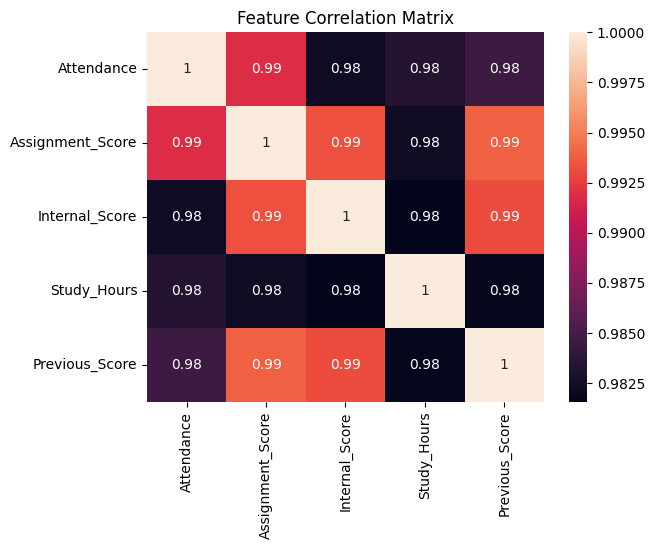

In [51]:
sns.heatmap(correlation, annot=True)

plt.title("Feature Correlation Matrix")
plt.show()

In [52]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
logistic_model = LogisticRegression(max_iter=1000)

In [56]:
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [57]:
y_pred_logistic = logistic_model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 1.0


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

               precision    recall  f1-score   support

Needs Support       1.00      1.00      1.00         1
         Pass       1.00      1.00      1.00         3

     accuracy                           1.00         4
    macro avg       1.00      1.00      1.00         4
 weighted avg       1.00      1.00      1.00         4



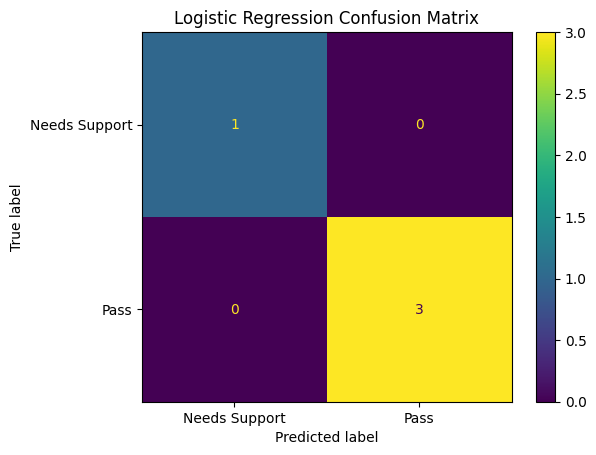

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [61]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [62]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 1.0


In [63]:
print(classification_report(y_test, y_pred_tree))

               precision    recall  f1-score   support

Needs Support       1.00      1.00      1.00         1
         Pass       1.00      1.00      1.00         3

     accuracy                           1.00         4
    macro avg       1.00      1.00      1.00         4
 weighted avg       1.00      1.00      1.00         4



In [64]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

In [65]:
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:", forest_accuracy)

Random Forest Accuracy: 1.0


In [66]:
print(classification_report(y_test, y_pred_forest))

               precision    recall  f1-score   support

Needs Support       1.00      1.00      1.00         1
         Pass       1.00      1.00      1.00         3

     accuracy                           1.00         4
    macro avg       1.00      1.00      1.00         4
 weighted avg       1.00      1.00      1.00         4



In [67]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0
2,Random Forest,1.0


In [68]:
new_student = pd.DataFrame({
    "Attendance": [82],
    "Assignment_Score": [75],
    "Internal_Score": [78],
    "Study_Hours": [3],
    "Previous_Score": [80]
})

In [69]:
prediction = forest_model.predict(new_student)

print("Predicted Outcome:", prediction[0])

Predicted Outcome: Pass
